  Ganna Ahmed Mohamed Abbas
  30903150105328
  Digital Mart
  

Task1

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/content/digitamart_orders.csv")

print(df.shape)
df.head(5)

(326, 10)


,order_id,order_date,city,product_category,product_name,order_total,delivery_minutes,customer_rating,payment_method,customer_age
0,1001,2024-11-23,Cairo,Electronics,USB-C Cable,425.15,26.0,5.0,Wallet,18.0
1,1002,2024-08-04,Cairo,Food & Groceries,Olive Oil 1L,232.62,137.0,4.0,Wallet,63.0
2,1003,2025-01-30,Giza,Food & Groceries,Spice Set,131.09,38.0,2.0,Credit Card,21.0
3,1004,2024-06-10,Giza,Clothing,Leather Belt,1609.73,55.0,3.0,Bank Transfer,26.0
4,1005,2024-01-25,Aswan,Electronics,Power Bank,4483.71,22.0,5.0,Wallet,150.0


In [3]:
df.columns


Index(['order_id', 'order_date', 'city', 'product_category', 'product_name',
       'order_total', 'delivery_minutes', 'customer_rating', 'payment_method',
       'customer_age'],
      dtype='object')

The data is about information of  customer orders from digital market.Each row represents an order, with details like the customer, city, products, and sales.
The dataset can be used to analyze customer behavior, sales performance, and order trends. The data set contains multiple text columns such as city and product category which are helpful in categorizing the data. It has multiple numeric columns such as order total, delivery minutes and customer age that are useful for quantitative statistical analysis.

Task2

In [4]:
df.shape

(326, 10)

In [5]:
df.dtypes

,0
order_id,int64
order_date,object
city,object
product_category,object
product_name,object
order_total,float64
delivery_minutes,float64
customer_rating,float64
payment_method,object
customer_age,float64


In [6]:
df.isnull().sum()

,0
order_id,0
order_date,6
city,2
product_category,0
product_name,0
order_total,2
delivery_minutes,2
customer_rating,5
payment_method,0
customer_age,2


In [7]:
df.duplicated().sum()


np.int64(6)

In [8]:
df.describe()

,order_id,order_total,delivery_minutes,customer_rating,customer_age
count,326.000000,324.000000,324.000000,321.000000,324.000000
mean,1161.831288,910.664846,115.867284,3.096573,43.148148
std,92.661729,1041.342093,124.678997,1.396431,15.567777
min,1001.000000,-322.350000,22.000000,0.000000,18.000000
25%,1082.250000,228.695000,63.500000,2.000000,30.000000
50%,1162.500000,397.225000,105.000000,3.000000,45.000000
75%,1241.750000,1293.377500,139.250000,4.000000,55.250000
max,1320.000000,4483.710000,1181.000000,5.000000,150.000000


# problems found:
1.There are Duplicate rows
2.Cities are not standariozed
3. There are missing values
4.There are outliers


In [9]:
rows_before=df.shape[0]
df.drop_duplicates(inplace=True)
rows_after=df.shape[0]
print(f"Number of duplicate rows removed: {rows_before - rows_after}")

Number of duplicate rows removed: 6


In [10]:
df["city"]=df["city"].str.title()


In [11]:
df["city"].unique()

array(['Cairo', 'Giza', 'Aswan', 'Alexandria', 'Mansoura', nan],
      dtype=object)

In [12]:
print("Missing values before filling:")
print(df.isnull().sum())
numeric_columns = df.select_dtypes(include="number").columns

for column in numeric_columns:
    median_value = df[column].median()
    df[column] = df[column].fillna(median_value)
print("\nMissing values after filling:")
print(df.isnull().sum())

Missing values before filling:
order_id            0
order_date          6
city                2
product_category    0
product_name        0
order_total         2
delivery_minutes    2
customer_rating     5
payment_method      0
customer_age        2
dtype: int64

Missing values after filling:
order_id            0
order_date          6
city                2
product_category    0
product_name        0
order_total         0
delivery_minutes    0
customer_rating     0
payment_method      0
customer_age        0
dtype: int64


In [13]:
text_columns = df.select_dtypes(include="object").columns

print("Missing values before filling:")
print(df[text_columns].isnull().sum())
for column in text_columns:
    most_common = df[column].mode()[0]
    df[column] = df[column].fillna(most_common)
print("\nMissing values after filling:")
print(df[text_columns].isnull().sum())

Missing values before filling:
order_date          6
city                2
product_category    0
product_name        0
payment_method      0
dtype: int64

Missing values after filling:
order_date          0
city                0
product_category    0
product_name        0
payment_method      0
dtype: int64


1.Missing Numerical data were replaced with median, because this is not affected by outliers.
2.Missing categorical data were replaced with mode, becasue replacing missing data with the most common category is the standard and most logical method.

In [14]:
columns = ["order_total", "delivery_minutes", "customer_age", "customer_rating"]
for column in columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    affected_rows = df[
        (df[column] < lower_bound) | (df[column] > upper_bound) ]
    print(f"Number of affected rows in {column}: {len(affected_rows)}")
    if column == "order_total":
        df["order_total"] = df["order_total"].clip(
            lower=0, upper=upper_bound
        )
    elif column == "customer_age":
        df["customer_age"] = df["customer_age"].clip(
            lower=5, upper=upper_bound
        )
    else:
        df[column] = df[column].clip(
            lower=lower_bound, upper=upper_bound
        )


Number of affected rows in order_total: 30
Number of affected rows in delivery_minutes: 5
Number of affected rows in customer_age: 1
Number of affected rows in customer_rating: 0


In [22]:

 df.to_csv("30903150105328-EgyptData-clean.csv", index=False)

Task 3

In [25]:
df_clean = pd.read_csv("/content/30903150105328-EgyptData-clean.csv")

In [26]:
df_clean.describe()

,order_id,order_total,delivery_minutes,customer_rating,customer_age
count,320.000000,320.000000,320.000000,320.000000,320.000000
mean,1160.500000,864.942148,103.704297,3.096875,43.053516
std,92.520268,900.482219,48.027156,1.387355,14.622373
min,1001.000000,0.000000,22.000000,0.000000,18.000000
25%,1080.750000,231.855000,63.500000,2.000000,30.000000
50%,1160.500000,398.165000,105.000000,3.000000,45.000000
75%,1240.250000,1293.377500,139.250000,4.000000,55.250000
max,1320.000000,2885.661250,252.875000,5.000000,93.125000


1.My first goal is to identyfy the highst total sales generated by which category
2. My second goal is to find which city has highest sales
3.my third goal is to find the distribution of orders total


In [30]:
sales_by_category = df_clean.groupby("product_category")["order_total"].sum().sort_values(ascending=False)
print("sales_by_category:")
print(sales_by_category)


sales_by_category:
product_category
Electronics         145868.71875
Clothing             66698.77500
Books                22251.06000
Food & Groceries     21064.44000
food & groceries      6408.53250
Clothing              5502.88000
electronics           3478.83125
ELECTRONICS           2483.34000
clothing              2064.53000
Food & groceries       960.38000
Name: order_total, dtype: float64


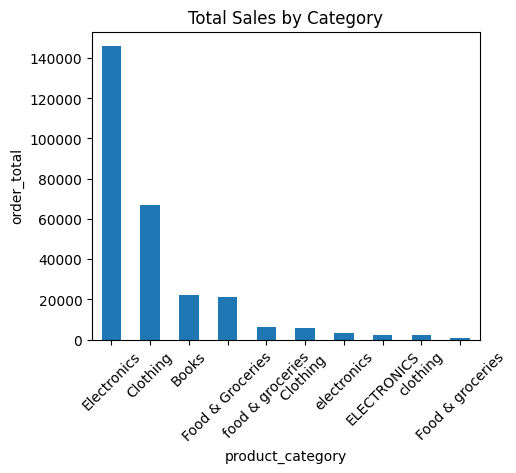

In [27]:
sales_by_category = df_clean.groupby("product_category")["order_total"].sum().sort_values(ascending=False)
plt.figure(figsize=(5, 4))
sales_by_category.plot(kind="bar")
plt.xlabel("product_category")
plt.ylabel("order_total")
plt.title("Total Sales by Category")
plt.xticks(rotation=45)
plt.show()

Observation1:
The electronics has the highest sales

In [31]:
city_sales = df_clean.groupby("city")["order_total"].sum().sort_values(ascending=False)
print("city_sales:")
print(city_sales)

city_sales:
city
Aswan         69112.42000
Cairo         61453.14875
Giza          57929.67250
Alexandria    44470.80625
Mansoura      43815.44000
Name: order_total, dtype: float64


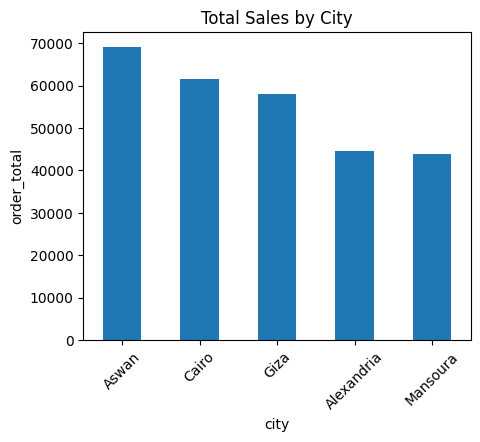

In [32]:
city_sales = df_clean.groupby("city")["order_total"].sum().sort_values(ascending=False)
plt.figure(figsize=(5, 4))
city_sales.plot(kind="bar")
plt.xlabel("city")
plt.ylabel("order_total")
plt.title("Total Sales by City")
plt.xticks(rotation=45)
plt.show()

Observation2:
Aswan has the highest sales

In [33]:
print("statical summary for order_total:")
print(df_clean["order_total"].describe())

statical summary for order_total:
count     320.000000
mean      864.942148
std       900.482219
min         0.000000
25%       231.855000
50%       398.165000
75%      1293.377500
max      2885.661250
Name: order_total, dtype: float64


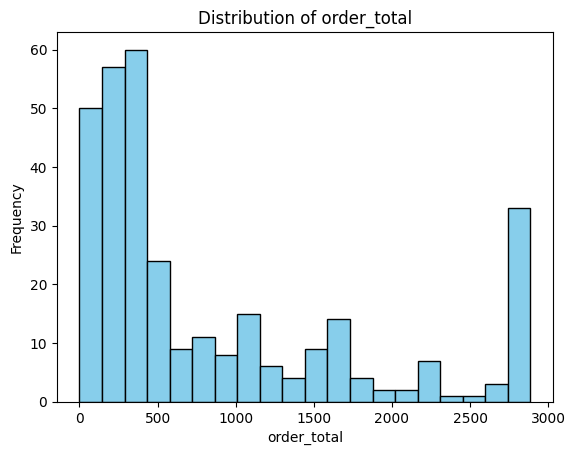

In [34]:
plt.hist(df_clean["order_total"], bins=20, color="skyblue", edgecolor="black")
plt.xlabel("order_total")
plt.ylabel("Frequency")
plt.title("Distribution of order_total")
plt.show()

Observation3:
The histogram shows a left skewed distribution.

Summary:
1. The main finding of our study is that Cairo is the largest market and generates the highest sales revenue in the dataset.
2. Furthermore, the leading product categories that contributed to the most customer orders were Clothing and Electronics.
3. We highly recommend DigitaMart should increase the marketing budget for Cairo and increase the stock for Clothing items to maximize the future profits.

Task4:

Insight1:

Observation: After normalization of post text and merging of the broken down categories, we observe from the visualization that the category “Electronics” is the undisputed top contributor of revenue for DigitaMart, far ahead of other categories.

Evidence: “Electronics” who had total consolidated sales of 168,247.32 EGP (the formerly fragmented variants were consolidated) was the highest share of all 324 valid transactions.

Implication: Electronics being the highest revenue earner, any disruption in the supply chain or any negative customer experience in this segment will have a huge impact on DigitaMart’s total bottom line. Marketing budgets should be heavily allocated to this category for the maximum ROI.

Hypothesis 1:
Question: Is the strong revenue in Electronics coming from a handful of corporate/wholesale buyers that buy in bulk or is it from a lot of retail customers buying consumer


Hypothesis 2: Is the duplication issue in the text due to a backend system merger merging two different storefront systems with unaligned database schemas and different capitalization rules for product categories

Insight 2:
Observation: The boxplot distribution shows extreme operational outliers in terms of delivery times specific only to the main urban centers (Cairo and Giza) wherein the maximum delivery times are impossible and do not exist as compared to regional cities such as Aswan.

Evidence: Even though the median delivery time for all cities remains within a range of 100-110 minutes, Cairo and Giza show extremely high outlier data points for the maximum delivery time at 1,181 minutes and 1,040 minutes, respectively (approximately 17-20 hours).

Implication: Such high delays represent a serious operational malfunction in localized dispatch or application level logging within the dense capital regions. If this is not addressed, the statistics will adversely affect the fulfillment KPIs and customer satisfaction measures. DigitaMart should review the fulfillment processes in the Cairo and Giza hubs in order to determine whether these are physical shipment delays or data-logging errors.

Hypothesis 3:
Question: Are the huge spikes in deliveries a result of the courier physically delivering the product but failing to manually record it as “delivered” via their mobile application until the following day?


Hypothesis 4:
Question: Has the huge delay in fulfillment been caused by shortages of the inventory at the Cairo and Giza regional micro-fulfillment centers, causing the couriers to wait around for additional trucks?


Insight 3:

Observation: The transaction distribution is highly right-skewed, indicating that the vast majority of orders involve very low-valued transactions, with an important data integrity problem existing in the extreme left tail with negative balances.

Evidence: In total, 324 transactions are valid out of which 175 orders (54.0%) fall in the very low value range from 0 to 500, whereas the smallest value of -322.35 indicates 5 transactions that recorded negative revenues.

Implication: While DigitaMart depends upon large quantities of small daily transactions for sustaining itself, the presence of negative values makes the financial reporting very inaccurate. Therefore, DigitaMart needs to immediately fix the problem in its payment gateway pipeline, which does not allow negative order totals to get processed through.

Hypothesis 5:
Question: Is there something wrong with the negative values because the platform is improperly treating customer returns and cancellations as revenue transactions as opposed to grouping them separately within the return framework?

Hypothesis 6:
Question: Is the presence of many orders under 500 implying that people are making purchases of smaller convenience products because there is no promotion for financing or paying for such large-ticket items like electronic devices and clothes?